In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from noshow.config import CLINIC_CONFIG
from pathlib import Path
from noshow.features.appointment_features import (
    add_appointments_last_days,
    add_appointments_same_day,
    add_days_since_created,
    add_days_since_last_appointment,
    add_minutes_early,
    add_time_features,
)
from noshow.features.no_show_features import prev_no_show_features
from noshow.features.patient_features import add_patient_features
from noshow.preprocessing.load_data import (
    load_appointment_csv,
    process_appointments,
    process_postal_codes,
)
from noshow.features.feature_pipeline import create_features
from noshow.visualisation.features_plots import feature_barplot, feature_scatter
from noshow.preprocessing.geo import haversine_distance

In [2]:
appointments_df = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")
appointments_df = process_appointments(appointments_df, CLINIC_CONFIG)

/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


--------
non unique index:
164030


In [3]:
all_postalcodes = process_postal_codes("../data/raw/NL.csv")
appointments_features = create_features(appointments_df, all_postalcodes)
appointments_features["no_show"] = (
        appointments_features["no_show"].replace({"no_show": "1", "show": "0"}).astype(int)
    )
features = ["hour",
            "weekday",
            "minutesDuration",
            "no_show",
            "prev_no_show",
            "prev_no_show_perc",
            "age",
            "dist_umcu",
            "prev_minutes_early",
            "earlier_appointments",
            "appointments_same_day",
            "appointments_last_days",
            "days_since_created",
            "days_since_last_appointment"]
appointments_features = appointments_features[features]

---
Index(['APP_ID', 'wat_id?', 'hoofdagenda', 'hoofdagenda_id', 'LA3401',
       'specialty_code', 'soort_consult', 'afspraak_code', 'end', 'arrival',
       'created', 'minutesDuration', 'status', 'status_code_original',
       'cancelationReason_code', 'cancelationReason_display', 'BIRTH_YEAR',
       'address_postalCodeNumbersNL', 'name', 'description', 'ziekenhuis',
       'soort_cons', 'ConsultTypeDescription', 'geen_idee', 'gender',
       'geen_id', 'no_show'],
      dtype='object')


<h3>minutesDuration<h3>

In [4]:
count = appointments_features[appointments_features['minutesDuration'] > 1400]
print(count['hour'].value_counts())

Series([], Name: count, dtype: int64)


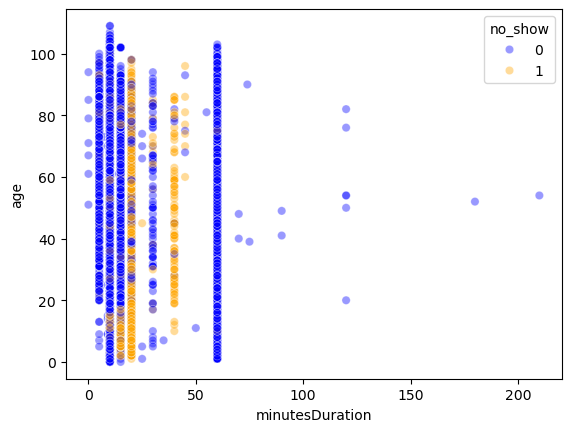

In [5]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="age", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('age')
plt.show()

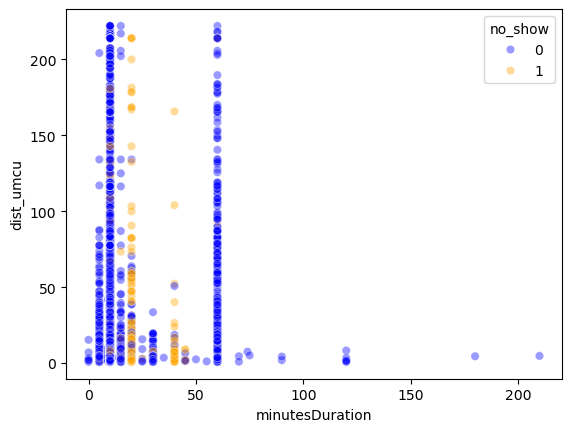

In [6]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="dist_umcu", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('dist_umcu')
plt.show()

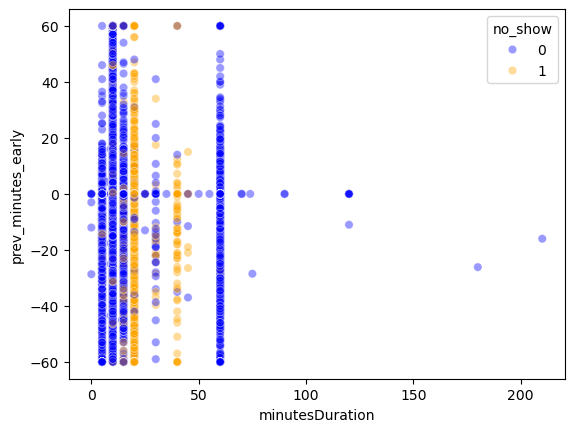

In [7]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="prev_minutes_early", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('prev_minutes_early')
plt.show()

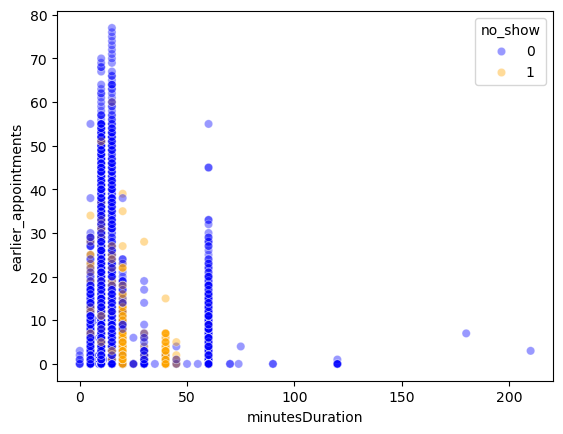

In [8]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="earlier_appointments", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('earlier_appointments')
plt.show()

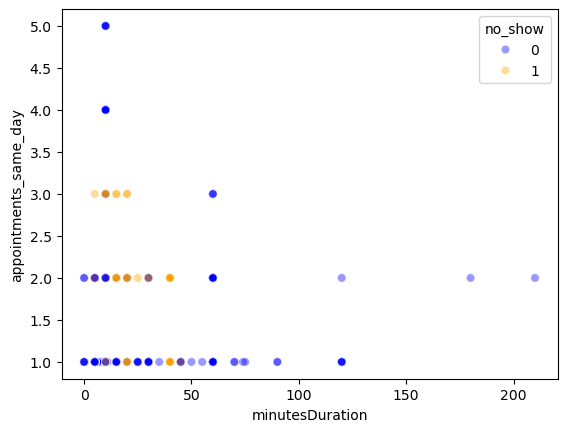

In [9]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="appointments_same_day", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('appointments_same_day')
plt.show()

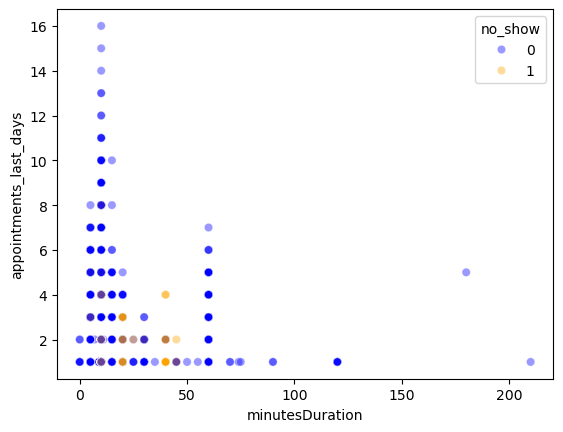

In [10]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('appointments_last_days')
plt.show()

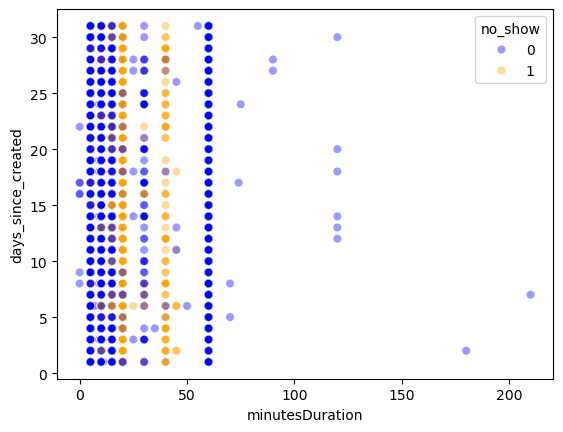

In [11]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('days_since_created')
plt.show()

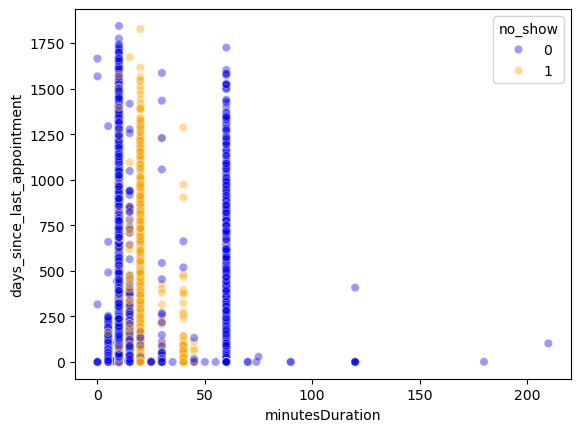

In [12]:
sns.scatterplot(data=appointments_features, x="minutesDuration", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('minutesDuration')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>age</h2>

In [13]:
count = appointments_features[appointments_features['dist_umcu'] > 214]
count = count[count['dist_umcu'] < 215]

print(count['dist_umcu'].isna().sum())

ziekenhuis_count = ( 
    count[count["no_show"] == "no_show"]
    .groupby("dist_umcu")["no_show"]
    .count()
    /
    count
    .groupby("dist_umcu")["no_show"]
    .count()
)
print(ziekenhuis_count)

0
dist_umcu
214.025748   NaN
214.482841   NaN
Name: no_show, dtype: float64


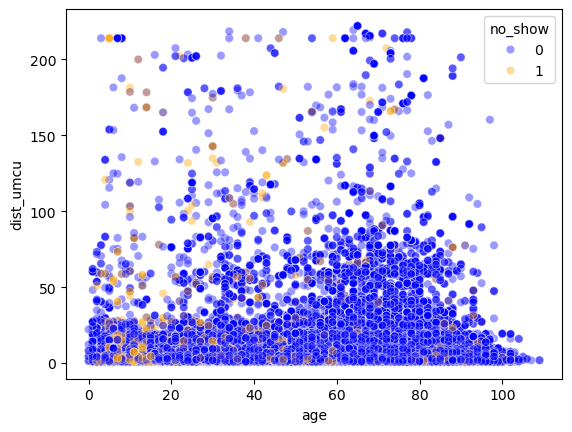

In [14]:
sns.scatterplot(data=appointments_features, x="age", y="dist_umcu", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('dist_umcu')
plt.show()
#the anomaly is postalcode: 9999 #TODO logbook

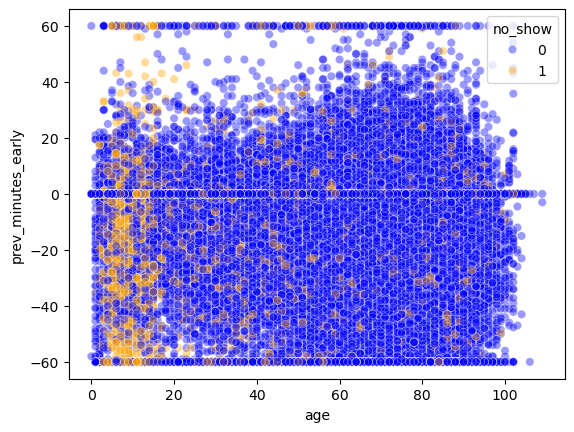

In [15]:
sns.scatterplot(data=appointments_features, x="age", y="prev_minutes_early", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('prev_minutes_early')
plt.show()

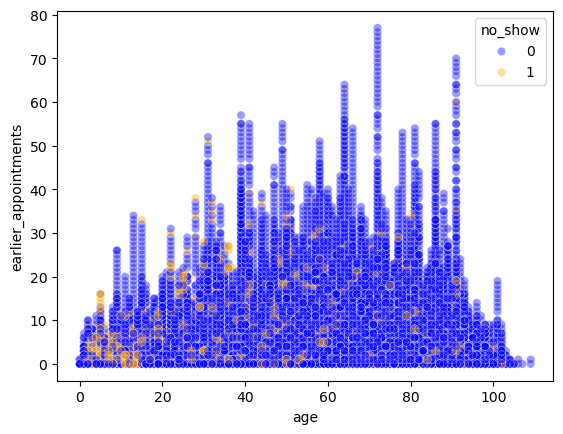

In [16]:
sns.scatterplot(data=appointments_features, x="age", y="earlier_appointments", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('earlier_appointments')
plt.show()

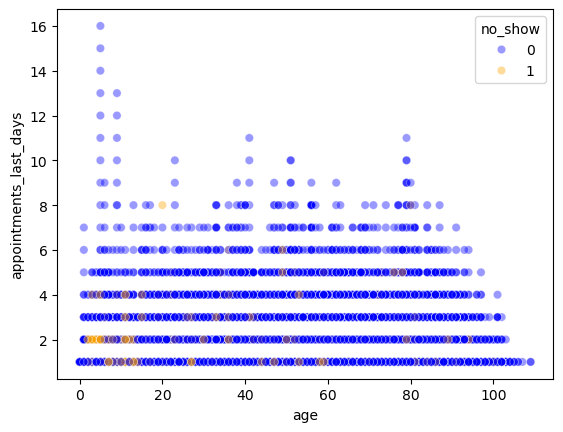

In [17]:
sns.scatterplot(data=appointments_features, x="age", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('appointments_last_days')
plt.show()

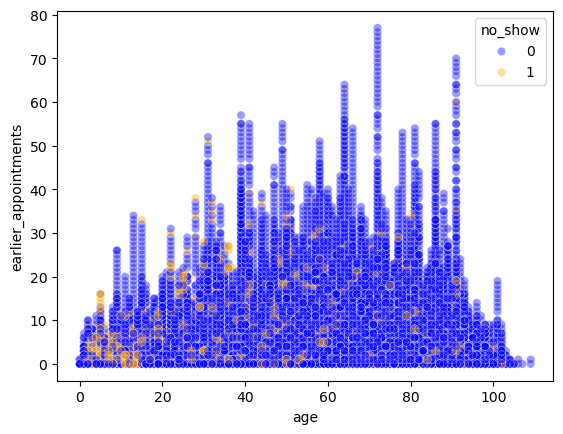

In [18]:
sns.scatterplot(data=appointments_features, x="age", y="earlier_appointments", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('earlier_appointments')
plt.show()

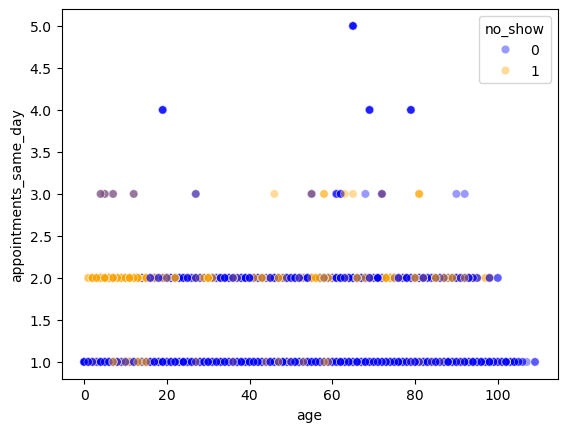

In [19]:
sns.scatterplot(data=appointments_features, x="age", y="appointments_same_day", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('appointments_same_day')
plt.show()

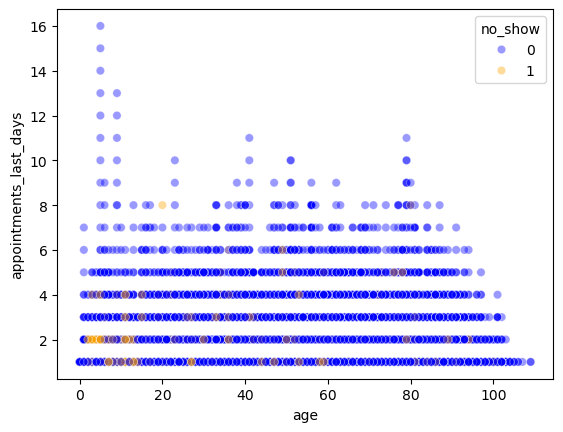

In [20]:
sns.scatterplot(data=appointments_features, x="age", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('appointments_last_days')
plt.show()

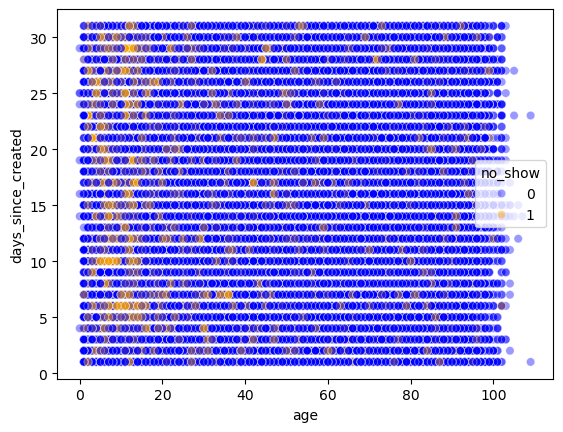

In [21]:
sns.scatterplot(data=appointments_features, x="age", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('days_since_created')
plt.show()

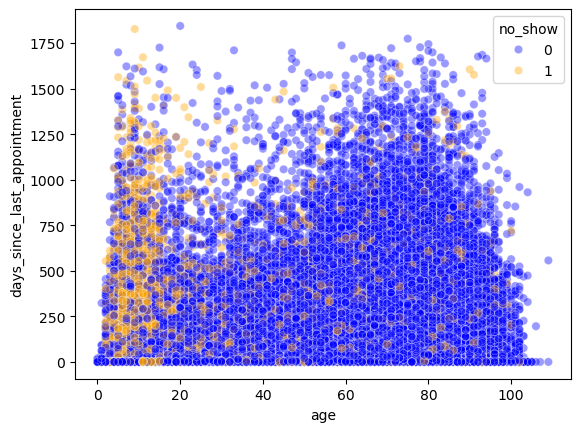

In [22]:
sns.scatterplot(data=appointments_features, x="age", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('age')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>dist_umcu</h2>

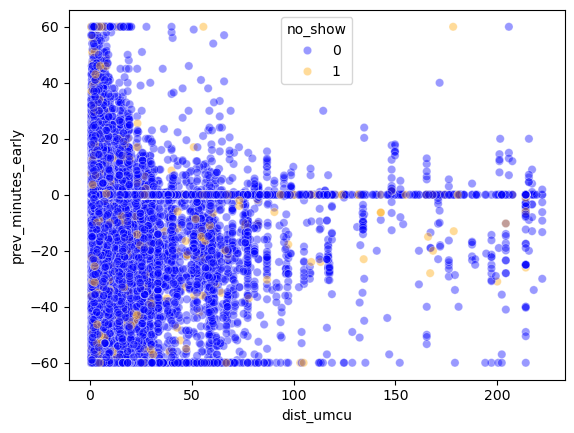

In [23]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="prev_minutes_early", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('prev_minutes_early')
plt.show()

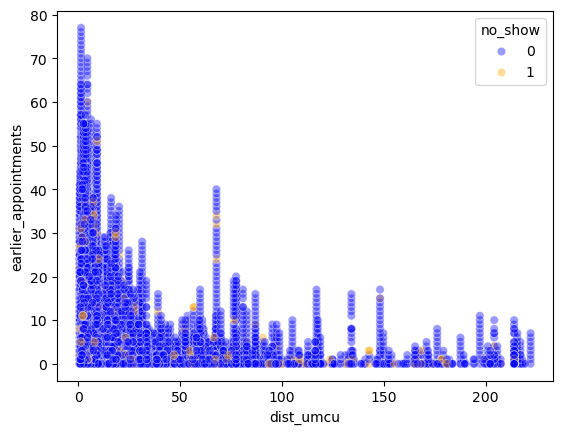

In [24]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="earlier_appointments", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('earlier_appointments')
plt.show()

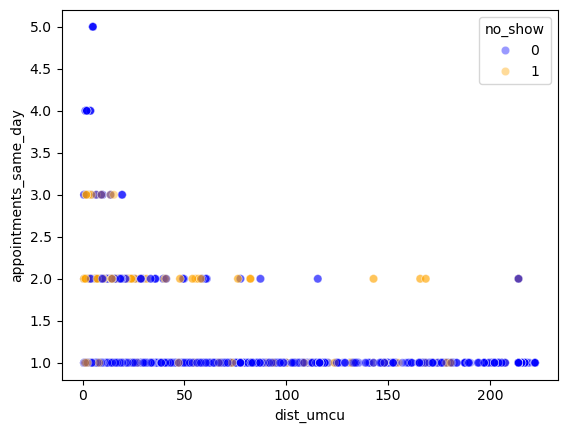

In [25]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="appointments_same_day", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('appointments_same_day')
plt.show()

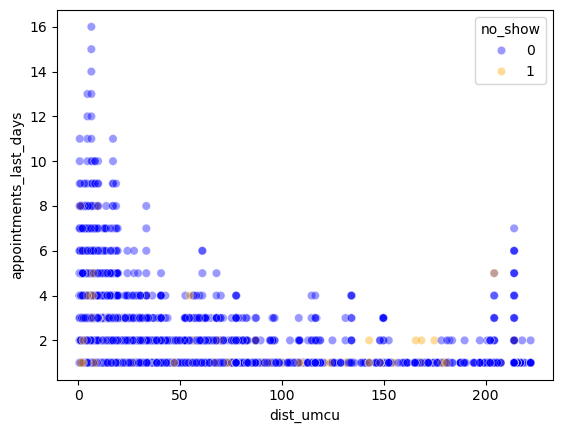

In [26]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('appointments_last_days')
plt.show()

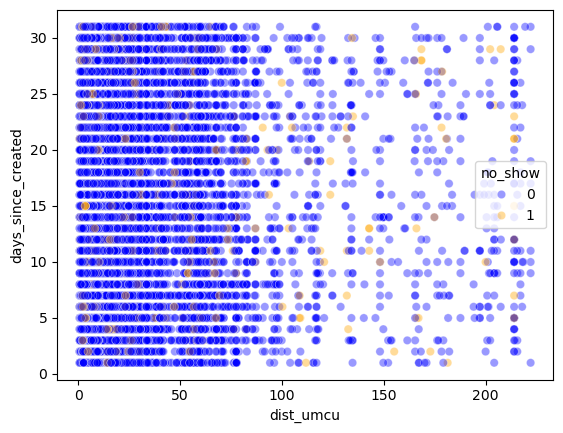

In [27]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('days_since_created')
plt.show()

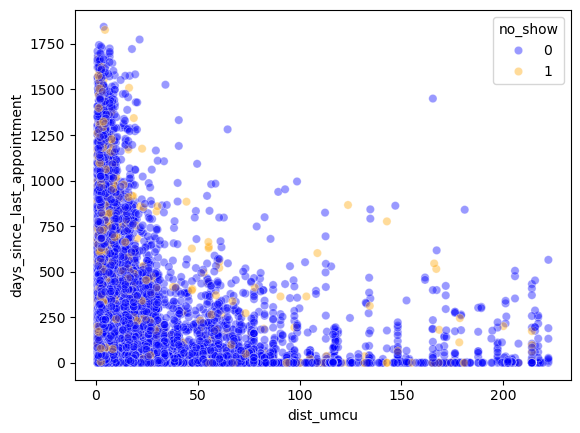

In [28]:
sns.scatterplot(data=appointments_features, x="dist_umcu", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('dist_umcu')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>prev_minutes_early</h2>

In [29]:
count = appointments_features[appointments_features['earlier_appointments'] > 280]
print(count)

Empty DataFrame
Columns: [hour, weekday, minutesDuration, no_show, prev_no_show, prev_no_show_perc, age, dist_umcu, prev_minutes_early, earlier_appointments, appointments_same_day, appointments_last_days, days_since_created, days_since_last_appointment]
Index: []


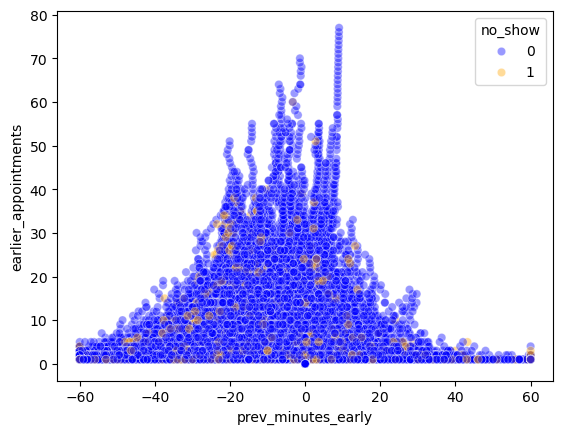

In [30]:
sns.scatterplot(data=appointments_features, x="prev_minutes_early", y="earlier_appointments", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('prev_minutes_early')
plt.ylabel('earlier_appointments')
plt.show()

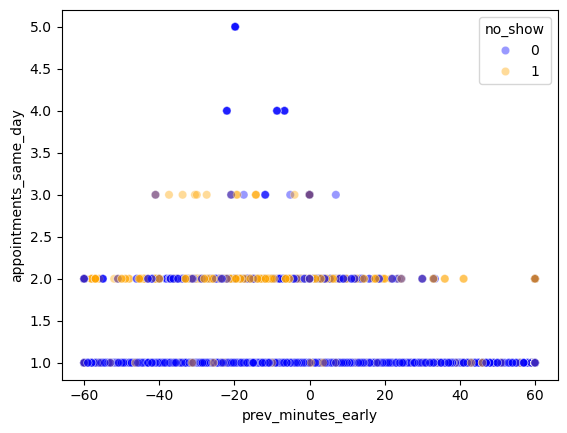

In [31]:
sns.scatterplot(data=appointments_features, x="prev_minutes_early", y="appointments_same_day", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('prev_minutes_early')
plt.ylabel('appointments_same_day')
plt.show()

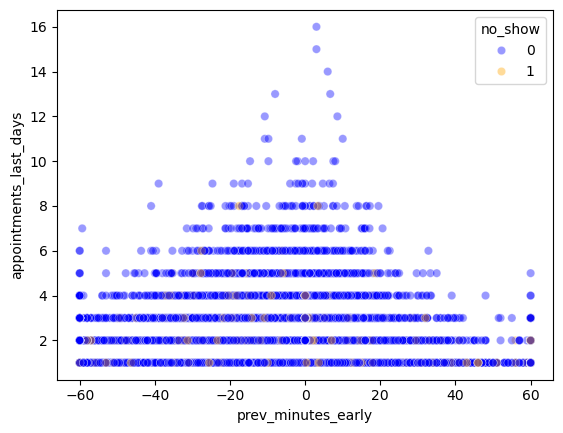

In [32]:
sns.scatterplot(data=appointments_features, x="prev_minutes_early", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('prev_minutes_early')
plt.ylabel('appointments_last_days')
plt.show()

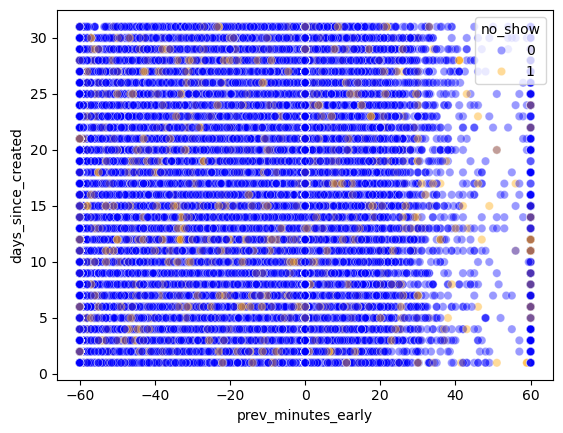

In [33]:
sns.scatterplot(data=appointments_features, x="prev_minutes_early", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('prev_minutes_early')
plt.ylabel('days_since_created')
plt.show()

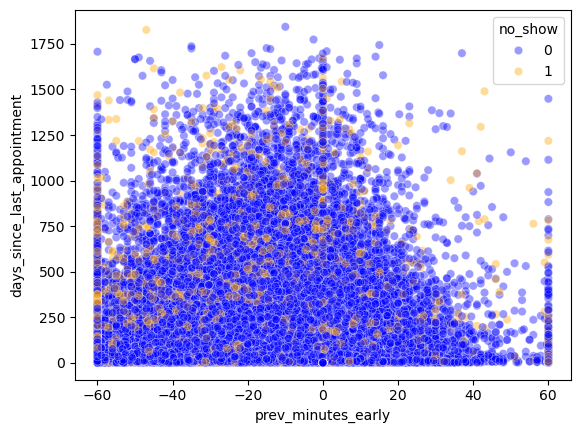

In [34]:
sns.scatterplot(data=appointments_features, x="prev_minutes_early", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('prev_minutes_early')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>earlier_appointments</h2>

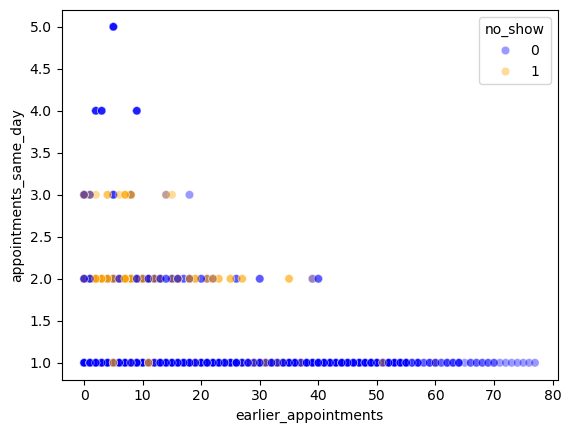

In [35]:
sns.scatterplot(data=appointments_features, x="earlier_appointments", y="appointments_same_day", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('earlier_appointments')
plt.ylabel('appointments_same_day')
plt.show()

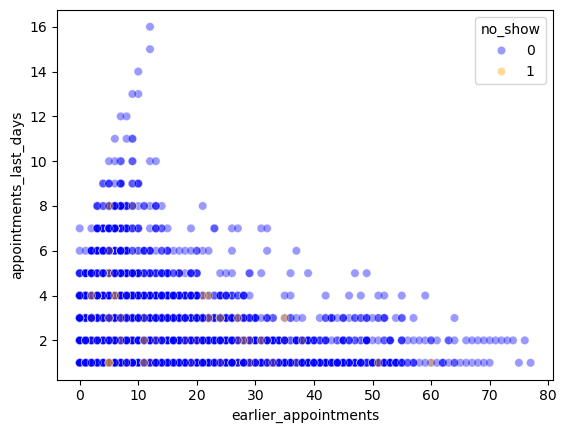

In [36]:
sns.scatterplot(data=appointments_features, x="earlier_appointments", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('earlier_appointments')
plt.ylabel('appointments_last_days')
plt.show()

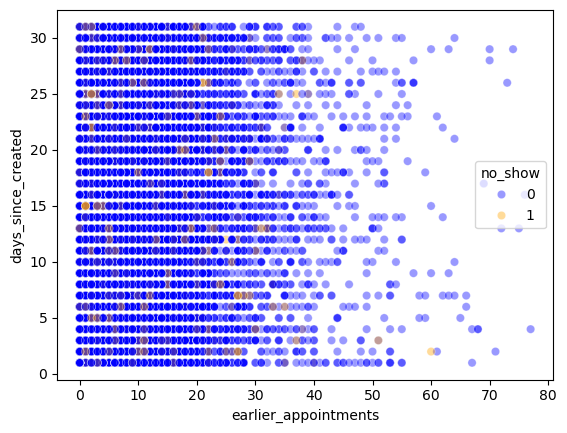

In [37]:
sns.scatterplot(data=appointments_features, x="earlier_appointments", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('earlier_appointments')
plt.ylabel('days_since_created')
plt.show()

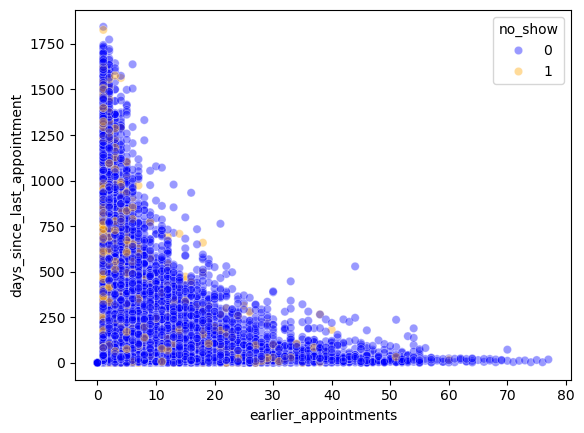

In [38]:
sns.scatterplot(data=appointments_features, x="earlier_appointments", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('earlier_appointments')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>appointments_same_day</h2>

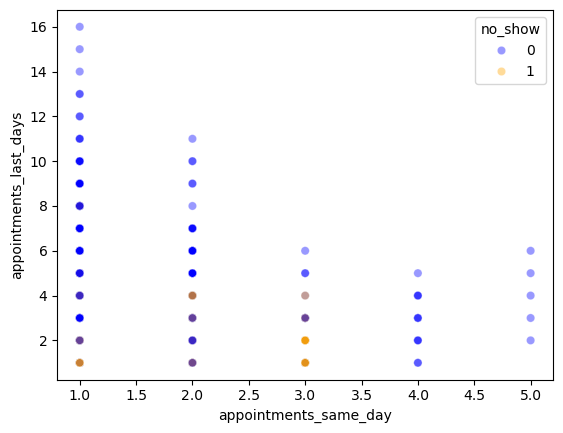

In [39]:
sns.scatterplot(data=appointments_features, x="appointments_same_day", y="appointments_last_days", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('appointments_same_day')
plt.ylabel('appointments_last_days')
plt.show()

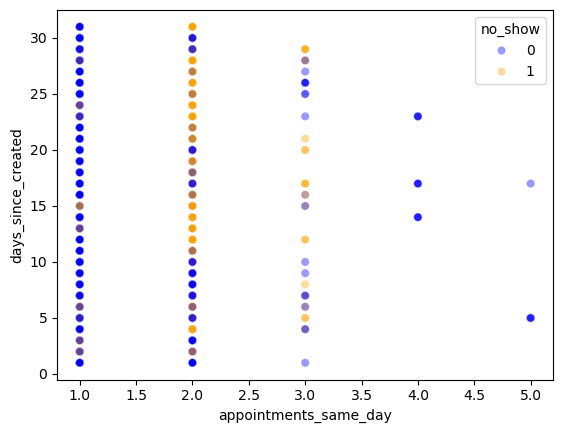

In [40]:
sns.scatterplot(data=appointments_features, x="appointments_same_day", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('appointments_same_day')
plt.ylabel('days_since_created')
plt.show()

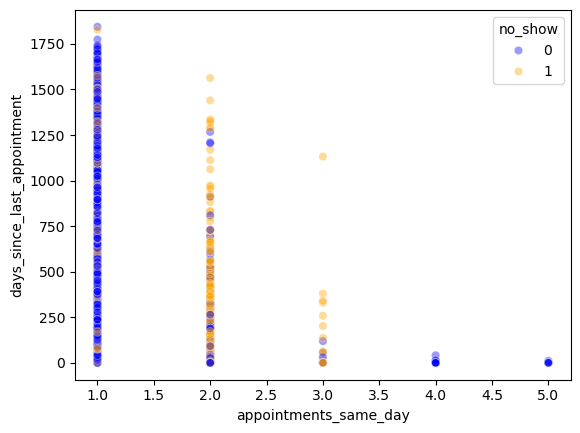

In [41]:
sns.scatterplot(data=appointments_features, x="appointments_same_day", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('appointments_same_day')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>appointments_last_days</h2>

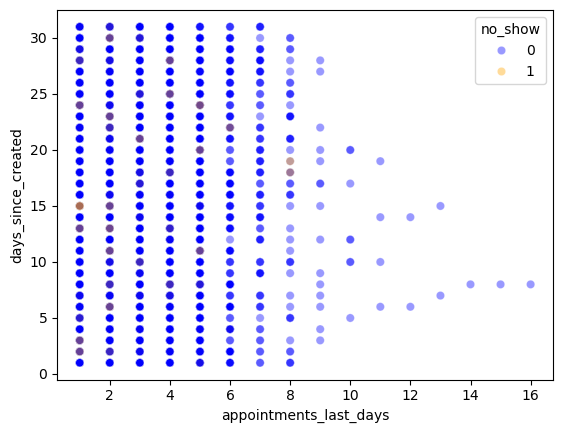

In [42]:
sns.scatterplot(data=appointments_features, x="appointments_last_days", y="days_since_created", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('appointments_last_days')
plt.ylabel('days_since_created')
plt.show()

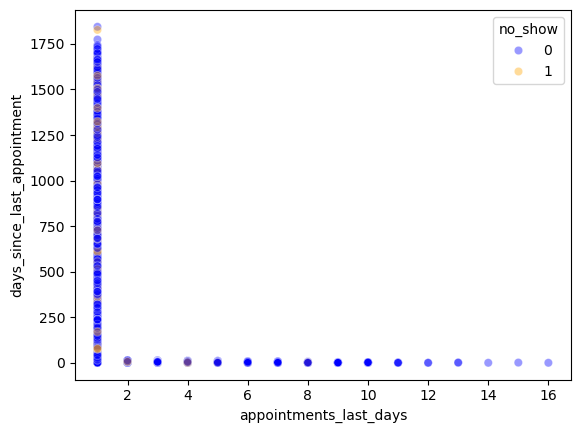

In [43]:
sns.scatterplot(data=appointments_features, x="appointments_last_days", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('appointments_last_days')
plt.ylabel('days_since_last_appointment')
plt.show()

<h2>days_since_created</h2>

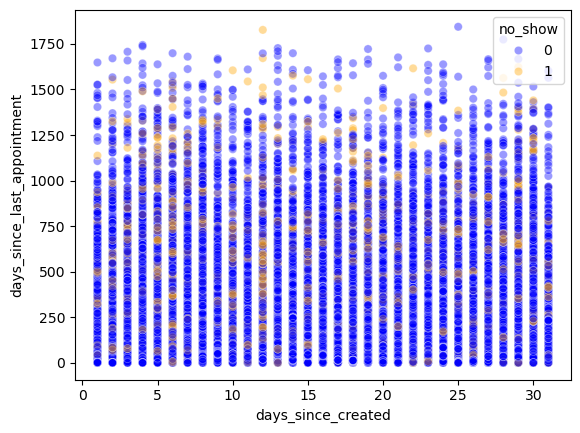

In [44]:
sns.scatterplot(data=appointments_features, x="days_since_created", y="days_since_last_appointment", hue="no_show", alpha=0.4, palette={0: "blue", 1:"orange"})
plt.xlabel('days_since_created')
plt.ylabel('days_since_last_appointment')
plt.show()

## pairplot

In [45]:
'''
sns.pairplot(appointments_features, hue ='no_show')
plt.show()
'''

"\nsns.pairplot(appointments_features, hue ='no_show')\nplt.show()\n"

In [46]:
test = appointments_features['minutesDuration'].value_counts()
print(test)

minutesDuration
10     147154
60       9787
20       3274
15       1241
5        1085
40        101
30         93
45         10
0           7
9           6
120         6
25          6
70          2
90          2
210         1
7           1
11          1
74          1
180         1
35          1
75          1
55          1
50          1
Name: count, dtype: int64


In [47]:
subset = appointments_features[appointments_features['minutesDuration'] == 0]

count = subset['no_show'].sum()
total_app = len(subset)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)

7
0.0


In [48]:
#check afspraak_code